# Notebook 03 - Sản phẩm và lợi nhuận

**Mục tiêu:** phân tích sản phẩm/danh mục theo doanh thu, số lượng bán, biên lợi nhuận, khuyến mãi, trả hàng và đánh giá. Notebook này giúp xác định nhóm sản phẩm nên mở rộng và nhóm gây rủi ro trải nghiệm.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "datathon-2026-round-1").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from EDA.constants.config import FIGURES_DIR, WEEKDAY_ORDER, AGE_ORDER, SIZE_ORDER
from EDA.utils.io import load_tables, build_order_metrics, build_order_item_metrics
from EDA.utils.plotting import setup_vietnamese_style, save_figure, format_money_axis, format_percent_axis, money_formatter
from EDA.utils.validation import quality_report, foreign_key_report

setup_vietnamese_style()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Tải dữ liệu và tạo fact dòng sản phẩm

In [2]:
tables = load_tables(["products", "order_items", "orders", "returns", "reviews"])
products, items, orders, returns, reviews = tables["products"], tables["order_items"], tables["orders"], tables["returns"], tables["reviews"]
display(quality_report(tables))
display(pd.DataFrame([
    foreign_key_report(items, products, "product_id", "product_id", "order_items", "products"),
    foreign_key_report(returns, products, "product_id", "product_id", "returns", "products"),
    foreign_key_report(reviews, products, "product_id", "product_id", "reviews", "products"),
]))
item = build_order_item_metrics(items).merge(products, on="product_id", how="left").merge(orders[["order_id", "order_date", "order_status"]], on="order_id", how="left")
item["cogs_total"] = item.quantity * item.cogs
item["gross_profit"] = item.net_sales - item.cogs_total
item["profit_margin"] = item.gross_profit / item.net_sales.replace(0, pd.NA)
display(Markdown(f"**Insight ngắn:** có {products.product_id.nunique():,} sản phẩm master, {item.product_id.nunique():,} sản phẩm từng bán. Lợi nhuận được tính ở grain dòng sản phẩm để tránh double count."))

,bảng,số dòng,số cột,ô thiếu,dòng trùng,dung lượng MB
1,order_items,714669,7,1152816,0,80.1100
2,orders,646945,8,0,0,182.5200
0,products,2412,8,0,0,0.8000
3,returns,39939,7,0,0,6.6800
4,reviews,113551,7,0,0,19.4900


,quan hệ,số khóa thiếu,tỷ lệ dòng bị ảnh hưởng,hợp lệ
0,order_items.product_id → products.product_id,0,0.0000,True
1,returns.product_id → products.product_id,0,0.0000,True
2,reviews.product_id → products.product_id,0,0.0000,True


**Insight ngắn:** có 2,412 sản phẩm master, 1,598 sản phẩm từng bán. Lợi nhuận được tính ở grain dòng sản phẩm để tránh double count.

## 2. Danh mục, phân khúc và biên lợi nhuận

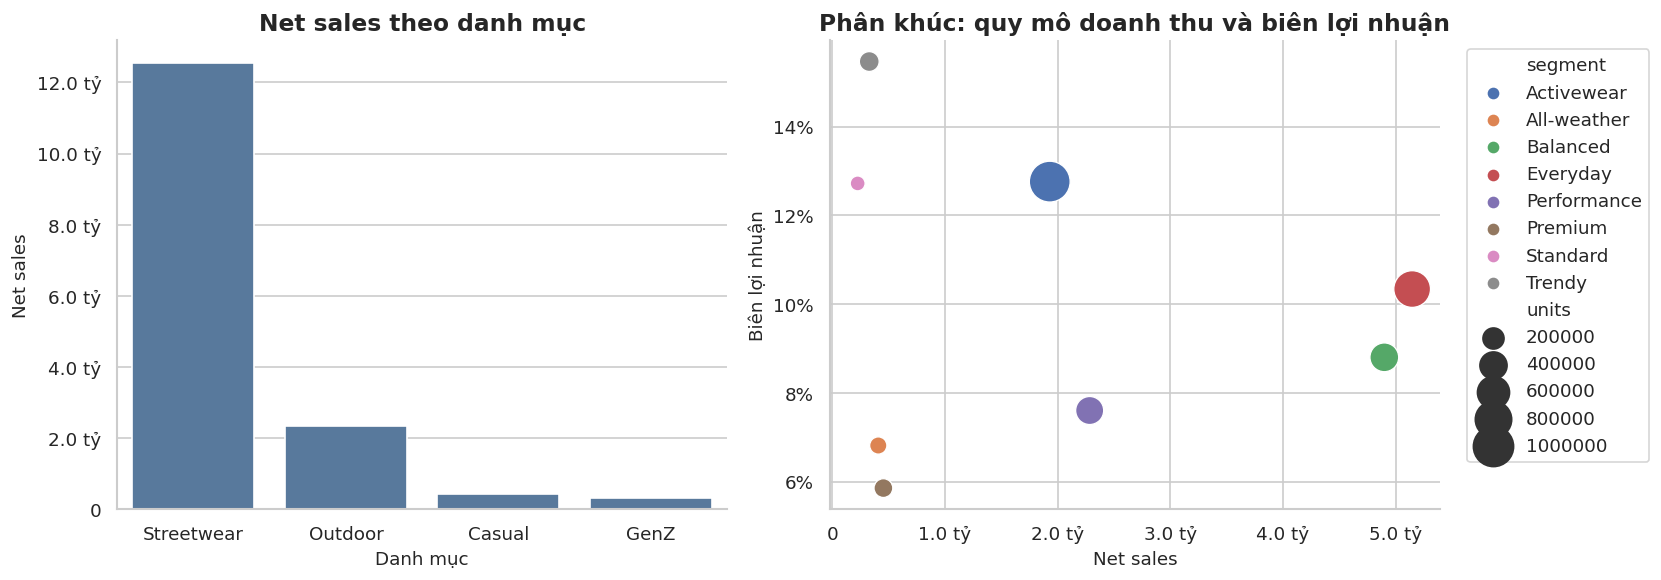

,category,net_sales,gross_sales,units,discount_amount,gross_profit,product_count,profit_margin,discount_rate
3,Streetwear,"12,558,477,099",13131346352.620001,1768826,572869253.450000,"1,165,807,512",877,9.28%,4.36%
2,Outdoor,"2,353,396,797",2494882754.200000,1170000,141485957.340000,"267,034,092",496,11.35%,5.67%
0,Casual,"440,285,194",460648383.350000,107469,20363189.600000,"33,740,765",114,7.66%,4.42%
1,GenZ,"328,710,176",343599095.360000,166848,14888919.710000,"50,836,377",111,15.47%,4.33%


**Insight ngắn:** `Streetwear` tạo net sales lớn nhất; `Trendy` có biên lợi nhuận cao nhất.

In [3]:
category = item.groupby("category", as_index=False).agg(net_sales=("net_sales", "sum"), gross_sales=("gross_sales", "sum"), units=("quantity", "sum"), discount_amount=("discount_amount", "sum"), gross_profit=("gross_profit", "sum"), product_count=("product_id", "nunique"))
category["profit_margin"] = category.gross_profit / category.net_sales
category["discount_rate"] = category.discount_amount / category.gross_sales
segment = item.groupby("segment", as_index=False).agg(net_sales=("net_sales", "sum"), units=("quantity", "sum"), gross_profit=("gross_profit", "sum"), product_count=("product_id", "nunique"))
segment["profit_margin"] = segment.gross_profit / segment.net_sales

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=category.sort_values("net_sales", ascending=False), x="category", y="net_sales", color="#4c78a8", ax=axes[0])
axes[0].set_title("Net sales theo danh mục"); axes[0].set_xlabel("Danh mục"); axes[0].set_ylabel("Net sales"); format_money_axis(axes[0])
sns.scatterplot(data=segment, x="net_sales", y="profit_margin", size="units", hue="segment", sizes=(80, 600), ax=axes[1])
axes[1].set_title("Phân khúc: quy mô doanh thu và biên lợi nhuận"); axes[1].set_xlabel("Net sales"); axes[1].set_ylabel("Biên lợi nhuận"); axes[1].xaxis.set_major_formatter(plt.FuncFormatter(money_formatter)); format_percent_axis(axes[1]); axes[1].legend(bbox_to_anchor=(1.03, 1), loc="upper left")
save_figure("03_product_profitability_category_segment", fig); plt.show()
display(category.sort_values("net_sales", ascending=False).style.format({"net_sales": "{:,.0f}", "gross_profit": "{:,.0f}", "profit_margin": "{:.2%}", "discount_rate": "{:.2%}"}))
display(Markdown(f"**Insight ngắn:** `{category.sort_values('net_sales', ascending=False).iloc[0].category}` tạo net sales lớn nhất; `{segment.sort_values('profit_margin', ascending=False).iloc[0].segment}` có biên lợi nhuận cao nhất."))

## 3. Pareto sản phẩm

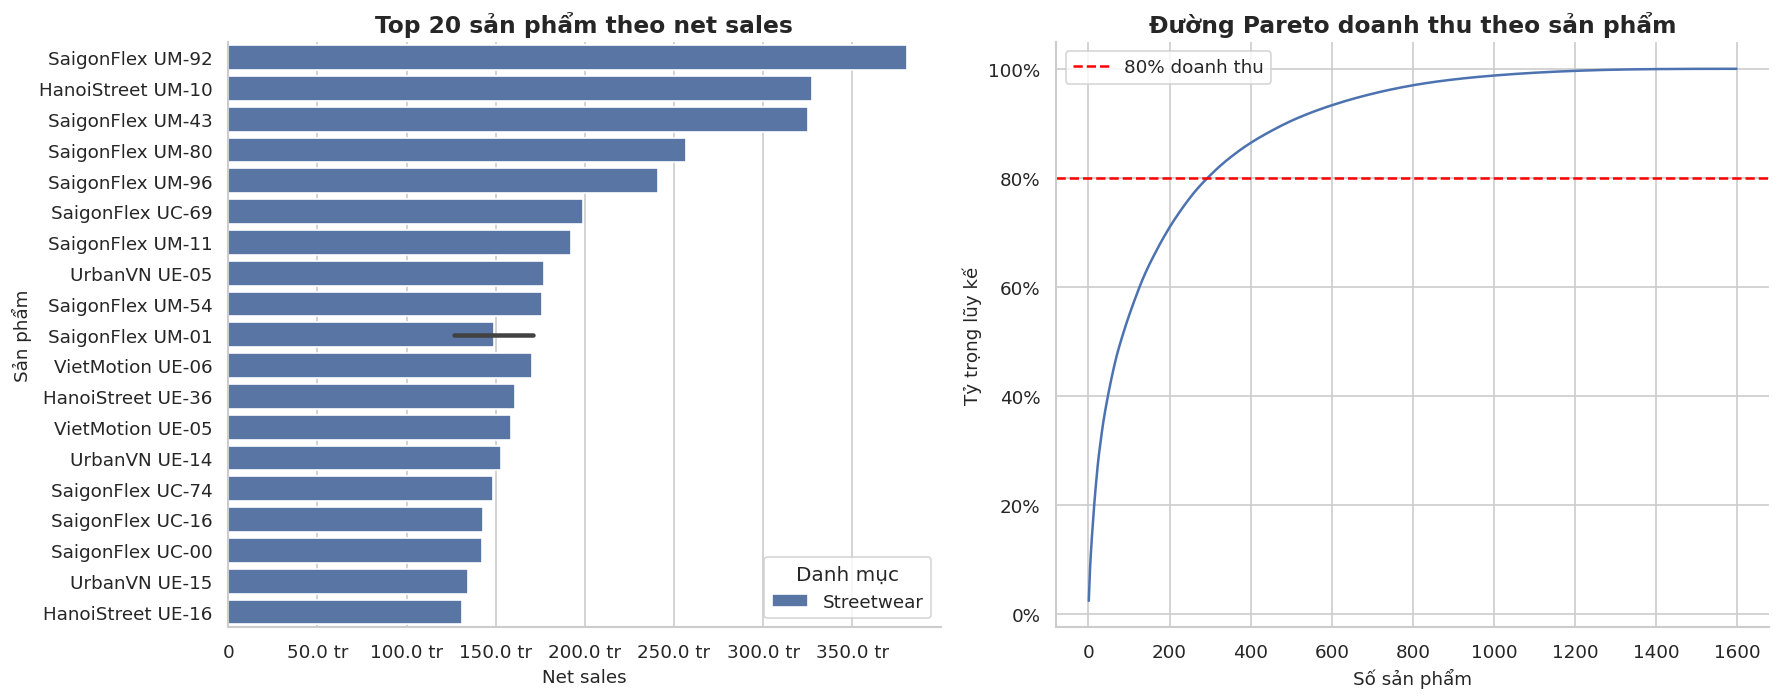

**Insight ngắn:** cần khoảng 294 sản phẩm để đạt 80% net sales; đây là nhóm hero SKU nên ưu tiên dự báo và quản trị tồn kho.

In [4]:
product_perf = item.groupby(["product_id", "product_name", "category", "segment"], as_index=False).agg(net_sales=("net_sales", "sum"), units=("quantity", "sum"), gross_profit=("gross_profit", "sum")).sort_values("net_sales", ascending=False)
product_perf["profit_margin"] = product_perf.gross_profit / product_perf.net_sales
product_perf["revenue_share"] = product_perf.net_sales / product_perf.net_sales.sum()
product_perf["cum_revenue_share"] = product_perf.revenue_share.cumsum()
top20 = product_perf.head(20)
products_for_80 = int((product_perf.cum_revenue_share <= .8).sum() + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=top20, y="product_name", x="net_sales", hue="category", dodge=False, ax=axes[0])
axes[0].set_title("Top 20 sản phẩm theo net sales"); axes[0].set_xlabel("Net sales"); axes[0].set_ylabel("Sản phẩm"); axes[0].xaxis.set_major_formatter(plt.FuncFormatter(money_formatter)); axes[0].legend(title="Danh mục")
axes[1].plot(range(1, len(product_perf) + 1), product_perf.cum_revenue_share); axes[1].axhline(.8, color="red", linestyle="--", label="80% doanh thu")
axes[1].set_title("Đường Pareto doanh thu theo sản phẩm"); axes[1].set_xlabel("Số sản phẩm"); axes[1].set_ylabel("Tỷ trọng lũy kế"); format_percent_axis(axes[1]); axes[1].legend()
save_figure("03_product_profitability_pareto", fig); plt.show()
display(Markdown(f"**Insight ngắn:** cần khoảng {products_for_80:,} sản phẩm để đạt 80% net sales; đây là nhóm hero SKU nên ưu tiên dự báo và quản trị tồn kho."))

## 4. Kích cỡ, trả hàng và đánh giá

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


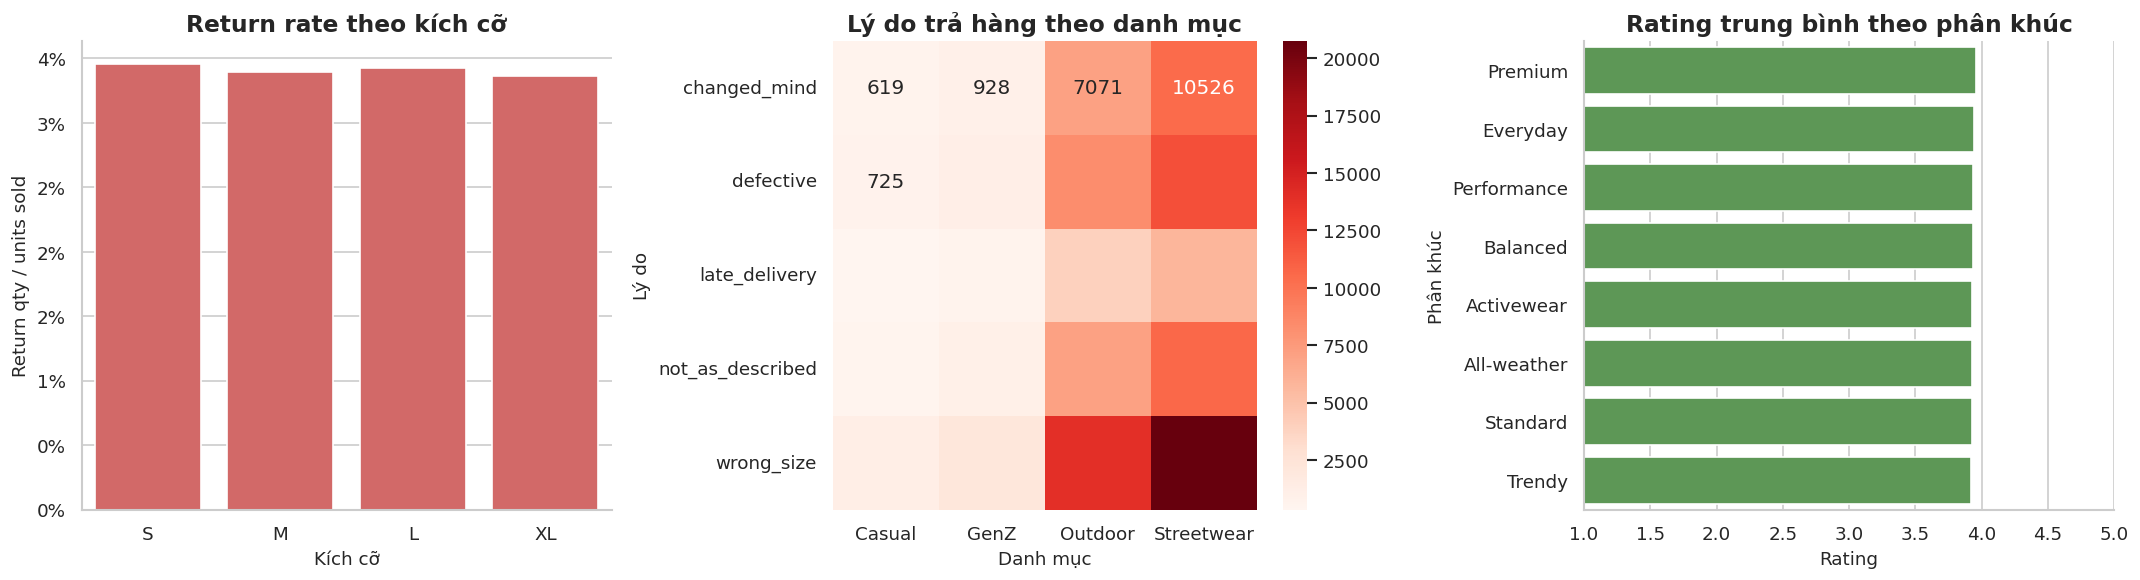

**Insight ngắn:** size `S` có return rate cao nhất; lý do trả hàng phổ biến nhất là `wrong_size`.

In [5]:
sold_size = item.groupby("size", as_index=False).agg(units_sold=("quantity", "sum"), item_lines=("product_id", "count"), net_sales=("net_sales", "sum"))
sold_size["size"] = pd.Categorical(sold_size["size"], SIZE_ORDER, ordered=True)
ret_prod = returns.merge(products, on="product_id", how="left")
ret_size = ret_prod.groupby("size", as_index=False).agg(return_rows=("return_id", "count"), return_qty=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
ret_size["size"] = pd.Categorical(ret_size["size"], SIZE_ORDER, ordered=True)
size_risk = sold_size.merge(ret_size, on="size", how="left").fillna({"return_rows": 0, "return_qty": 0, "refund_amount": 0})
size_risk["return_qty_rate"] = size_risk.return_qty / size_risk.units_sold
reason_cat = ret_prod.groupby(["category", "return_reason"], as_index=False).agg(return_qty=("return_quantity", "sum"))
rev_prod = reviews.merge(products, on="product_id", how="left")
quality = rev_prod.groupby("segment", as_index=False).agg(avg_rating=("rating", "mean"), review_count=("review_id", "count"), low_rating_rate=("rating", lambda x: (x <= 2).mean()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=size_risk.sort_values("size"), x="size", y="return_qty_rate", color="#e45756", ax=axes[0])
axes[0].set_title("Return rate theo kích cỡ"); axes[0].set_xlabel("Kích cỡ"); axes[0].set_ylabel("Return qty / units sold"); format_percent_axis(axes[0])
sns.heatmap(reason_cat.pivot(index="return_reason", columns="category", values="return_qty").fillna(0), cmap="Reds", annot=True, fmt=".0f", ax=axes[1])
axes[1].set_title("Lý do trả hàng theo danh mục"); axes[1].set_xlabel("Danh mục"); axes[1].set_ylabel("Lý do")
sns.barplot(data=quality.sort_values("avg_rating", ascending=False), y="segment", x="avg_rating", color="#54a24b", ax=axes[2])
axes[2].set_title("Rating trung bình theo phân khúc"); axes[2].set_xlabel("Rating"); axes[2].set_ylabel("Phân khúc"); axes[2].set_xlim(1, 5)
save_figure("03_product_profitability_returns_reviews", fig); plt.show()
display(Markdown(f"**Insight ngắn:** size `{size_risk.sort_values('return_qty_rate', ascending=False).iloc[0]['size']}` có return rate cao nhất; lý do trả hàng phổ biến nhất là `{ret_prod.return_reason.value_counts().idxmax()}`."))

## 5. Kết luận chung

In [6]:
display(Markdown(f'''
**Kết luận chung - Sản phẩm và lợi nhuận**

- Không nên đánh giá danh mục chỉ theo doanh thu; cần kết hợp margin, discount rate, return rate và rating.
- Khoảng {products_for_80:,} sản phẩm tạo 80% net sales, phù hợp để ưu tiên kiểm soát tồn kho và dự báo cấp SKU.
- Rủi ro trả hàng theo kích cỡ/lý do trả hàng gợi ý hành động cụ thể: cải thiện size guide, mô tả sản phẩm và kiểm soát chất lượng.
'''))


**Kết luận chung - Sản phẩm và lợi nhuận**

- Không nên đánh giá danh mục chỉ theo doanh thu; cần kết hợp margin, discount rate, return rate và rating.
- Khoảng 294 sản phẩm tạo 80% net sales, phù hợp để ưu tiên kiểm soát tồn kho và dự báo cấp SKU.
- Rủi ro trả hàng theo kích cỡ/lý do trả hàng gợi ý hành động cụ thể: cải thiện size guide, mô tả sản phẩm và kiểm soát chất lượng.
